In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

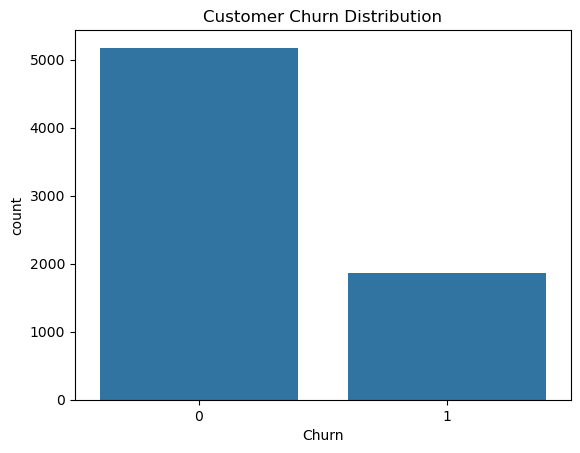

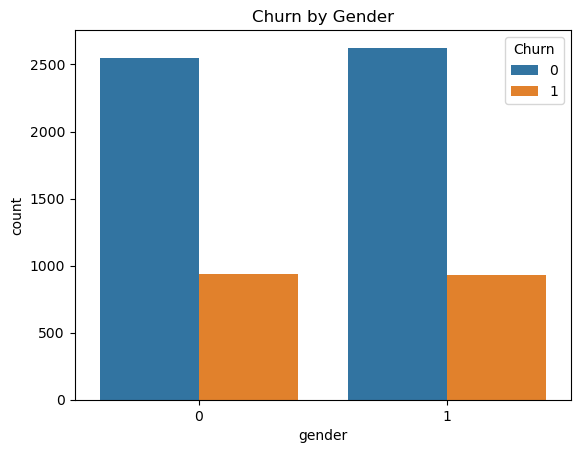

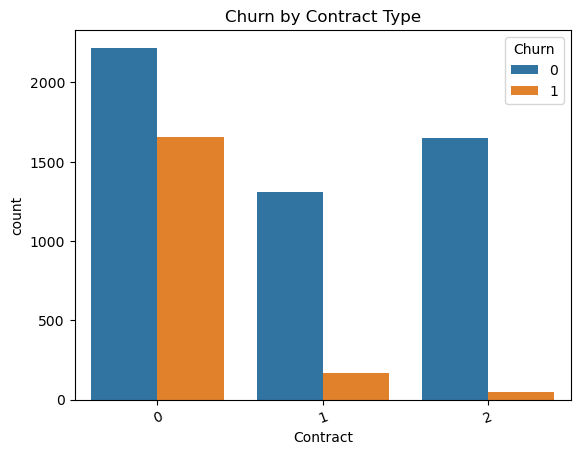

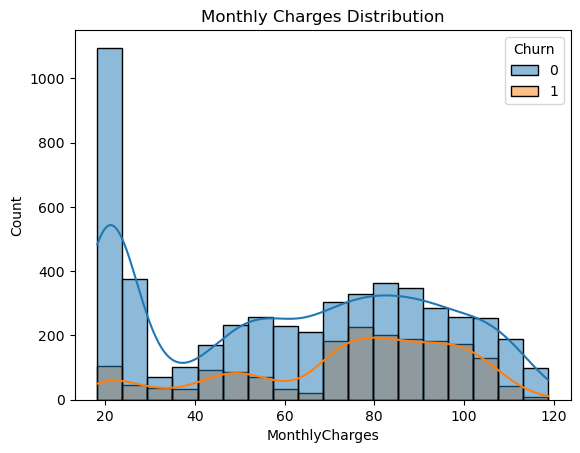

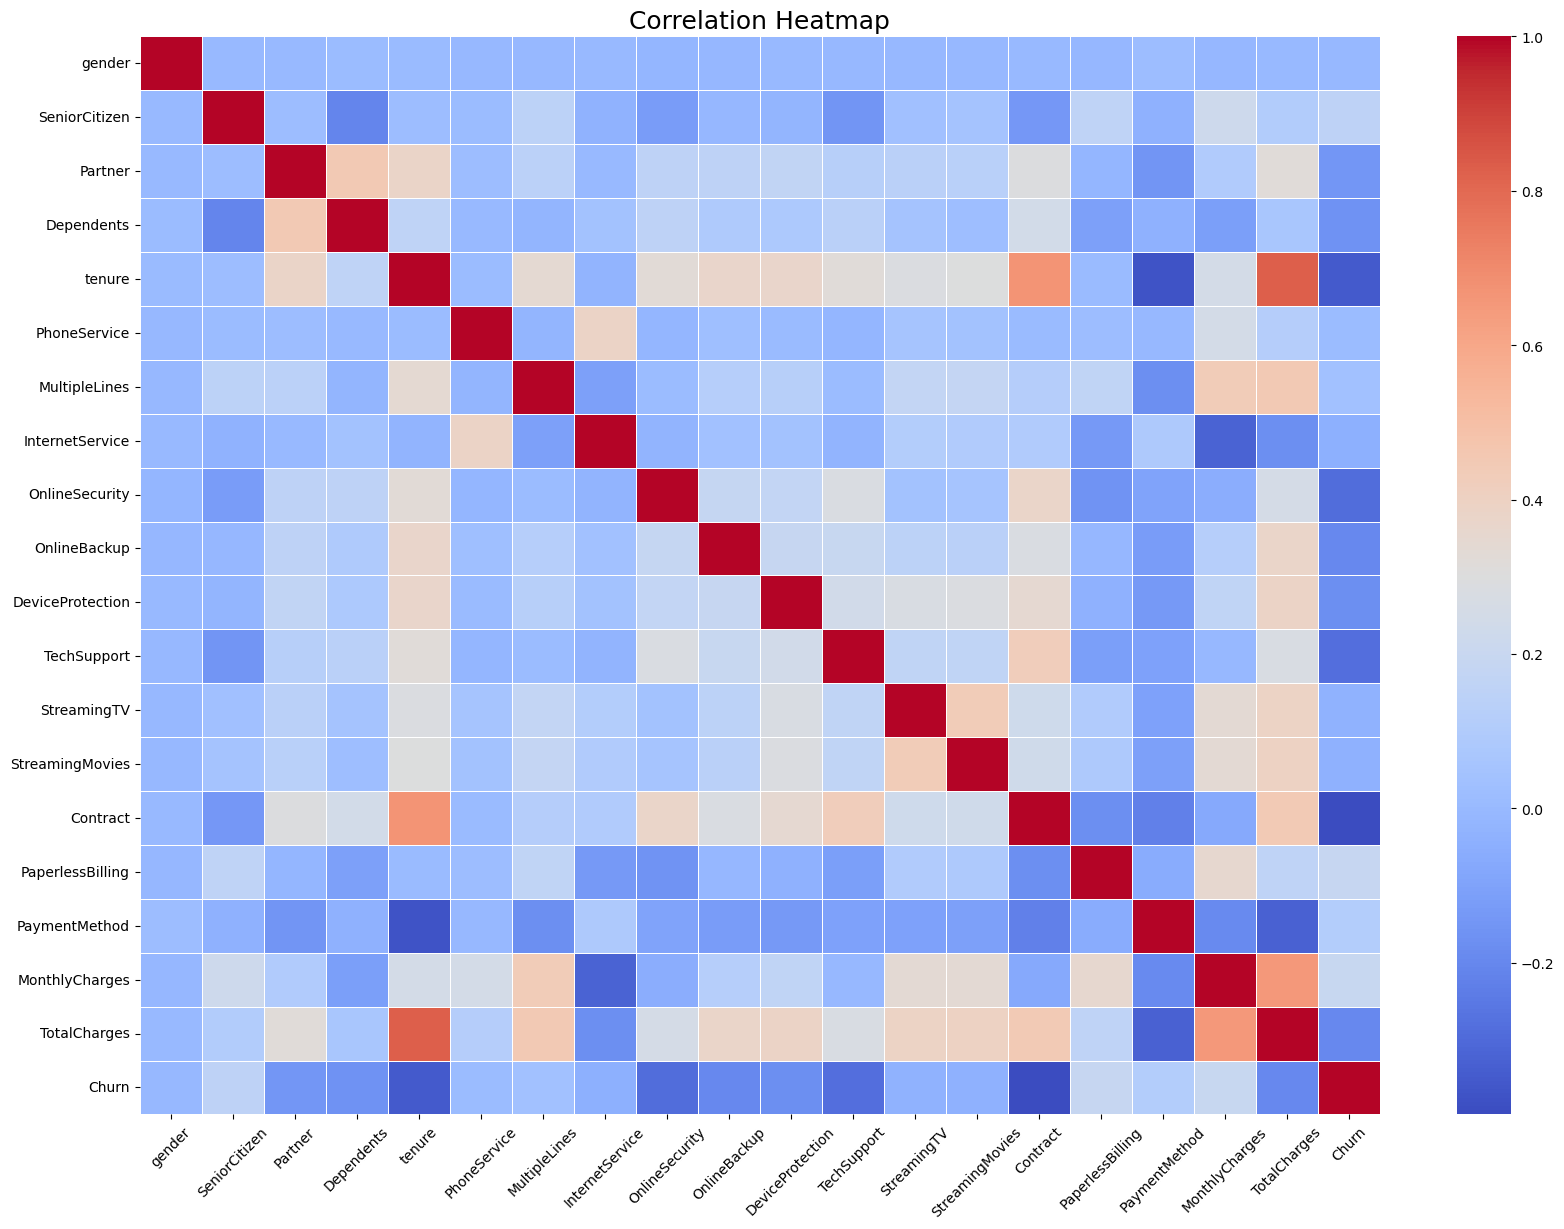

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from xgboost import XGBClassifier

# Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display First 5 Rows
print(df.head())

# Dataset Information
print(df.info())

# Check Missing Values
print(df.isnull().sum())

# Convert TotalCharges to Numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill Missing Values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID Column
df.drop('customerID', axis=1, inplace=True)

# Encode Categorical Columns
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

# Split Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- Logistic Regression ----------------
lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

# ---------------- Random Forest ----------------
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

# ---------------- XGBoost ----------------
xgb_model = XGBClassifier(eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("XGBoost ROC-AUC:",
      roc_auc_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

# ---------------- EDA Visualizations ----------------

# Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Churn by Gender
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Churn by Gender")
plt.show()

# Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

# Monthly Charges Distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

# Correlation Heatmap
# Correlation Heatmap
plt.figure(figsize=(20,14))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()